In [208]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [320]:
import json
from pprint import pprint

paths_path = r"info\paths.json"
with open(paths_path, 'r') as f:
    paths = json.load(f)

# paths = {
#     "minmax og": r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128',
#     "zscore std dev 0": r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128',
#     "zscore std dev 1e-8": r'jobs\20251122_150635\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000',
#     "zscore std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "zscore std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "slopes on 0 std dev": r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000",
#     "log on std dev 0": r"jobs\20251121_234325\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "log on std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234345\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "log on std dev 1e-7": r"jobs\20251121_234356\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 1e-8": r"jobs\20251122_150633\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234746\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251121_234754\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
#     "split vector std dev 0": r"A:\Projects\DM + RL\RL\jobs\20251121_234802\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
# }

model_name = "LA large mlp zscore-norm wd1e-3"

path = paths[model_name]
# path = r'jobs\20251111_165459\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251115_225402\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h1024-512-256-images'
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012420\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012429\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"

# model1
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# # model2
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# model3 (slopes)
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000"

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [321]:
# loading the model in

import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [322]:
if metrics_data['args']['fc1_final_activation'] != 'none':
    raise DeprecationWarning("This model has a poor final activation and is deprecated for evaluation.")

In [323]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=25, bias=True)
    (8): Identity()
  )
)

In [324]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 1372185


In [325]:
from environment import CoronagraphEnvironment
import copy


def revive_jsonable(obj):
    if isinstance(obj, dict):
        if obj.get("__type") == "slice":
            return slice(obj.get("start"), obj.get("stop"), obj.get("step"))
        return {k: revive_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [revive_jsonable(v) for v in obj]
    return obj


raw_env_config = metrics_data['dataset_meta']['environment_config']
env_config = revive_jsonable(copy.deepcopy(raw_env_config))
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')
if 'env_delta_t' in env_config:
    env_config['delta_t'] = env_config.pop('env_delta_t')

env_config['obs_noise_level'] = 0.0  # disable observation noise for evaluation

env = CoronagraphEnvironment(**env_config)

initializing coronagraph env. might take a minute.


In [326]:
print(f"basis type: {env.basis}")
print(f"for consistency, please ensure models were trained on the same basis.")

basis type: orthogonal
for consistency, please ensure models were trained on the same basis.


### Model history

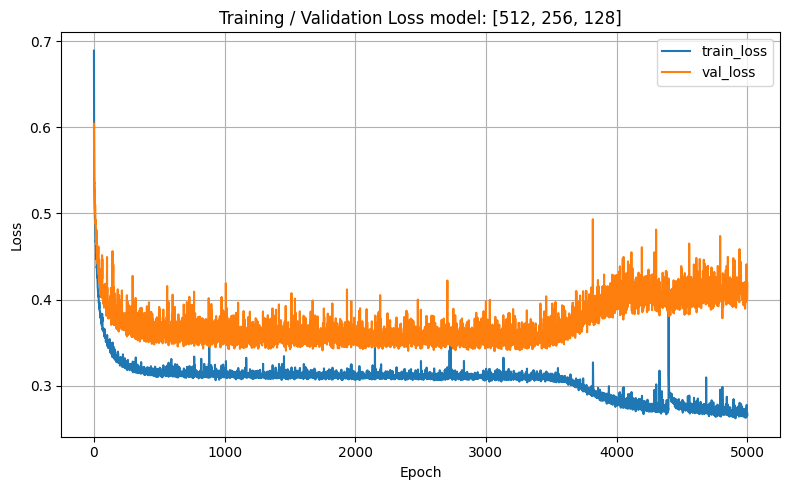

In [327]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(f'Training / Validation Loss model: {metrics_data["args"]["fc1_hidden"]}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [295]:
env_config

{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 7,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_noise_level': 0.0,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'orthogonal',
 'mode_range': slice(0, 25, None),
 'delta_t': 0.001}

### Model properties:

In [296]:
from train_job import NORMALIZERS
import tqdm

regenerate_properties = True 

if regenerate_properties:
    delta_t = 1e-3 # metrics_data['dataset_meta']['dataset_config']['delta_t']
    delta_t *= 100 # due to a data scaling error, need this to compensate.
    # dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
    train_type = metrics_data['args'].get('train_type', 'images')
    slopes_train = False # (train_type == "slopes")
    split_vector = metrics_data['args'].get('split_vector', False)
    print(f"Using split vector: {split_vector}")
    print(f"Using slopes: {slopes_train}")

    norm_func_name = metrics_data['x_norm']['type']
    if norm_func_name == "log+zscore": norm_func_name = "log"

    x_norm_func = NORMALIZERS[norm_func_name]
    params = metrics_data['x_norm'].copy()
    params.pop('type')

    y_mean = metrics_data['y_norm']['mean']
    y_std = metrics_data['y_norm']['std']

    num_modes = env_config["num_modes"]

    samples = 500
    noise_levels = np.linspace(5e-7, 3e-6, samples)
    repetitions = 1

    cos_similarities = np.zeros(samples)
    initial_contrasts = np.zeros(samples)
    final_contrasts = np.zeros(samples)
    predictions = np.zeros(shape=(samples, repetitions, num_modes))
    truths = np.zeros(shape=(samples, repetitions, num_modes))

    def get_model_output(imgs):
        with torch.no_grad():
            imgs = torch.asarray(imgs).unsqueeze(0)
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))

            y_pred = model(imgs_norm)
            y_pred = y_pred.squeeze(0).numpy()

            if split_vector:
                vec_part = y_pred[:-1]
                magnitude_part = y_pred[-1]
                work_pred = vec_part
                work_pred /= np.linalg.norm(vec_part)
                work_pred *= magnitude_part
            else:
                work_pred = y_pred
        
        work_pred = work_pred * y_std + y_mean

        return work_pred

    for i, noise in enumerate(tqdm.tqdm(noise_levels)):
        contrast_differences = []

        for j in range(repetitions):
            env.deformable_mirror.flatten()
            env.set_random_dm(noise=noise)
            original = np.array(env.deformable_mirror.actuators.copy())
            initial_contrast = env.get_contrast(delta_t=1e15)
            initial_contrasts[i] += initial_contrast / repetitions

            imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

            work_pred = get_model_output(imgs)
                
            truths[i, j, :] = original
            predictions[i, j, :] = work_pred

            net_action = original - work_pred

            env.deformable_mirror.flatten()
            env.deformable_mirror.actuators = net_action
            final_contrast = env.get_contrast(delta_t=1e15)
            final_contrasts[i] += final_contrast / repetitions

            cos_sim = np.dot(work_pred, original) / (np.linalg.norm(work_pred) * np.linalg.norm(original))
            cos_similarities[i] += cos_sim / repetitions

Using split vector: False
Using slopes: False


100%|██████████| 500/500 [00:26<00:00, 18.86it/s]


In [297]:
import pickle
from time import time

if regenerate_properties:
    with open(f'evals/LA_evals/eval_{model_name}.pkl', 'wb') as f:
        pickle.dump({
            "noise_levels": noise_levels,
            "initial_contrasts": initial_contrasts,
            "final_contrasts": final_contrasts,
            "cos_similarities": cos_similarities,
            "predictions": predictions,
            "truths": truths
        }, f)
else:
    with open(f'evals/eval_{model_name}.pkl', 'rb') as f:
        eval_data = pickle.load(f)
        noise_levels = eval_data["noise_levels"]
        initial_contrasts = eval_data["initial_contrasts"]
        final_contrasts = eval_data["final_contrasts"]
        cos_similarities = eval_data["cos_similarities"]
        predictions = eval_data["predictions"]
        truths = eval_data["truths"]

In [298]:
## Some derived metrics
contrast_improvements = initial_contrasts / final_contrasts


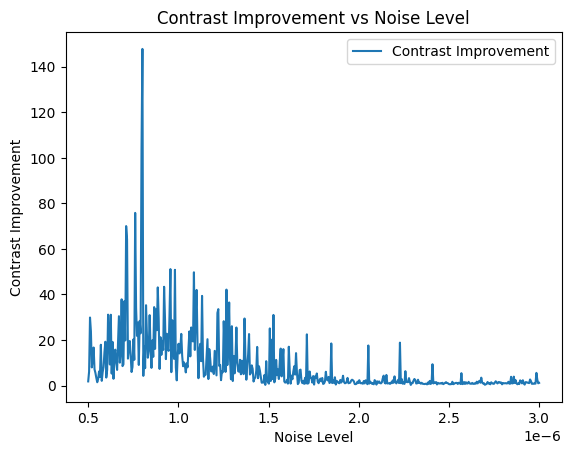

In [299]:
## Visualizations
plt.plot(noise_levels, contrast_improvements, label='Contrast Improvement')
plt.xlabel('Noise Level')
plt.ylabel('Contrast Improvement')
plt.title('Contrast Improvement vs Noise Level')
plt.legend()
plt.show()

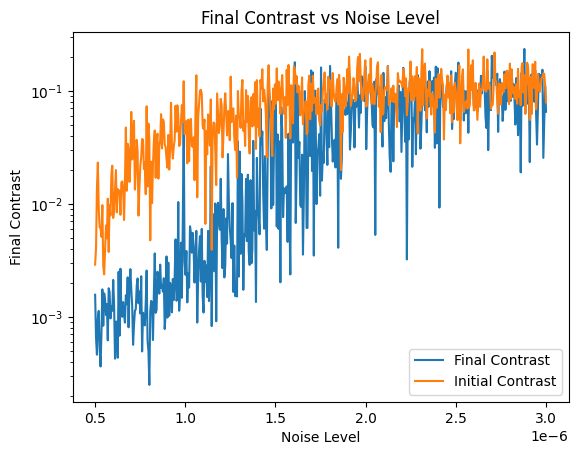

In [300]:
plt.plot(noise_levels, final_contrasts, label='Final Contrast')
plt.plot(noise_levels, initial_contrasts, label='Initial Contrast')
plt.xlabel('Noise Level')
plt.ylabel('Final Contrast')
plt.title('Final Contrast vs Noise Level')
plt.yscale('log')
plt.legend()
plt.show()

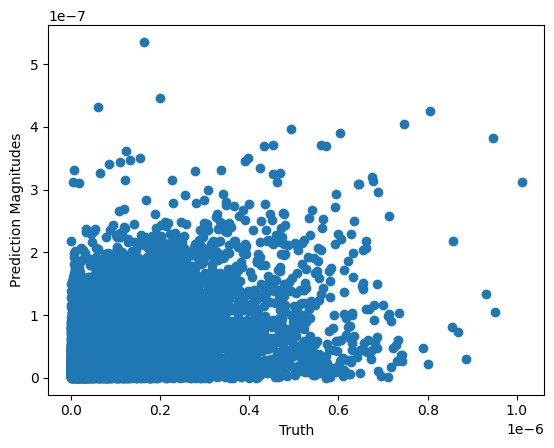

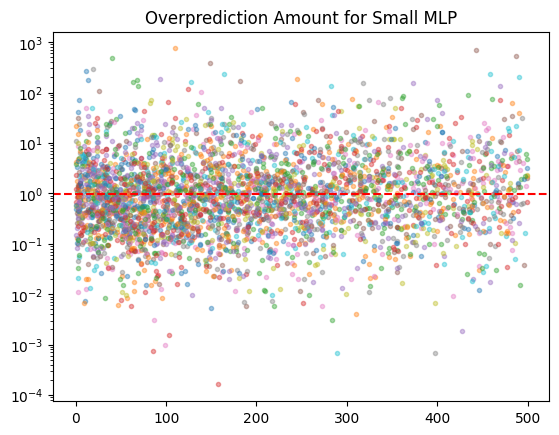

In [301]:
prediction_magnitudes = np.linalg.norm(predictions, axis=1)
truth_magnitudes = np.linalg.norm(truths, axis=1)

plt.scatter(truth_magnitudes, prediction_magnitudes)
plt.ylabel("Prediction Magnitudes")
plt.xlabel("Truth")
plt.show()

overprediction_amount = np.subtract(prediction_magnitudes, truth_magnitudes) / truth_magnitudes
median_overprediction = np.median(overprediction_amount)
plt.plot(overprediction_amount, '.', alpha=0.4)
plt.title("Overprediction Amount for Small MLP")
plt.axhline(y=np.mean(overprediction_amount), color="red", linestyle='--')
plt.yscale('log')
plt.show()


np.float64(-0.3556320729067397)